<a href="https://colab.research.google.com/github/nmansour67/skills-introduction-to-github1/blob/main/Empathy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# COMPETENCY-BASED MENTORSHIP — ML ANALYSIS PIPELINE
# Authors: Ali Taher & Nabil Mansour
# American University of Beirut | Faculty of Medicine & Medical Center
# Focus: Empathy, Patient-Doctor Relationship, Professionalism,
#         and the Human Side of Medicine
# ============================================================
# Run in Google Colab: Runtime → Run All
# ============================================================

# ============================================================
# SECTION 1: INSTALL & IMPORT
# ============================================================

print("=" * 65)
print("  COMPETENCY-BASED MENTORSHIP — EMPATHY & PROFESSIONALISM")
print("  Authors: Ali Taher & Nabil Mansour | AUB Medicine")
print("=" * 65)
print("\n[1/12] Installing required packages...")

# Core installs
import subprocess, sys
pkgs = [
    "openpyxl", "nltk", "wordcloud", "gensim",
    "shap", "scikit-learn", "matplotlib", "seaborn",
    "pandas", "numpy", "scipy"
]
for pkg in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"],
                   capture_output=True)

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from io import BytesIO
import re
import os
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("vader_lexicon", quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from scipy.stats import chi2_contingency
import shap

# Plotting style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#F7F9FB",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.family": "serif",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
PALETTE = ["#1B3A5C", "#2E86AB", "#A23B72", "#F18F01", "#C73E1D",
           "#3B1F2B", "#44BBA4", "#E94F37", "#393E41", "#5C4742"]

print("[1/12] ✓ All packages installed and imported.\n")




  COMPETENCY-BASED MENTORSHIP — EMPATHY & PROFESSIONALISM
  Authors: Ali Taher & Nabil Mansour | AUB Medicine

[1/12] Installing required packages...
[1/12] ✓ All packages installed and imported.



In [2]:
# ============================================================
# SECTION 2: DATA LOADING — Upload Excel File
# ============================================================

print("[2/12] Please upload your Excel file now...")

try:
    from google.colab import files
    uploaded = files.upload()
    if not uploaded:
        raise ValueError("No file uploaded.")
    fname = list(uploaded.keys())[0]
    data_bytes = uploaded[fname]
    xl = pd.ExcelFile(BytesIO(data_bytes))
    print(f"[2/12] ✓ File '{fname}' uploaded successfully.")
except Exception as e:
    # Fallback: if running locally, specify path here
    LOCAL_PATH = "Competency_Based_Mentorship.xlsx"
    if os.path.exists(LOCAL_PATH):
        xl = pd.ExcelFile(LOCAL_PATH)
        fname = LOCAL_PATH
        print(f"[2/12] ✓ Loaded local file: {LOCAL_PATH}")
    else:
        raise FileNotFoundError(
            "Could not load file. In Google Colab, use the upload prompt. "
            "Locally, place 'Competency_Based_Mentorship.xlsx' in the working directory."
        ) from e

print(f"      Sheets detected: {xl.sheet_names}\n")




[2/12] Please upload your Excel file now...


Saving Competency Based Mentorship.xlsx to Competency Based Mentorship.xlsx
[2/12] ✓ File 'Competency Based Mentorship.xlsx' uploaded successfully.
      Sheets detected: ['Competency Model', 'Teaching (2)', 'Teaching', 'TQ1PB', 'TQ2NB', 'TQ3CITPB', 'TQ4CITNB', 'Clinical', 'CQ1PB', 'CQ2NB', 'CQ3CITPB', 'CQ4CITNB', 'Research', 'RQ1PB', 'RQ2NB', 'RQ3CITPB', 'RQ4CITNB', 'Administrative', 'AQ1PB', 'AQ2NB', 'AQ3CITPB', 'AQ4CITNB', 'AnythingToAdd', 'Sheet3']



In [3]:
# ============================================================
# SECTION 3: INITIAL INSPECTION & MULTI-SHEET SYNTHESIS
# ============================================================

print("[3/12] Reading and synthesising all sheets...")

# Sheets that contain interview data
INTERVIEW_SHEETS = [
    "Teaching (2)", "Teaching",
    "TQ1PB", "TQ2NB", "TQ3CITPB", "TQ4CITNB",
    "Clinical",
    "CQ1PB", "CQ2NB", "CQ3CITPB", "CQ4CITNB",
    "Research",
    "RQ1PB", "RQ2NB", "RQ3CITPB", "RQ4CITNB",
    "Administrative",
    "AQ1PB", "AQ2NB", "AQ3CITPB", "AQ4CITNB",
    "AnythingToAdd",
]

# Domain mapping
DOMAIN_MAP = {
    "Teaching": "Teaching", "Teaching (2)": "Teaching",
    "TQ1PB": "Teaching", "TQ2NB": "Teaching",
    "TQ3CITPB": "Teaching", "TQ4CITNB": "Teaching",
    "Clinical": "Clinical",
    "CQ1PB": "Clinical", "CQ2NB": "Clinical",
    "CQ3CITPB": "Clinical", "CQ4CITNB": "Clinical",
    "Research": "Research",
    "RQ1PB": "Research", "RQ2NB": "Research",
    "RQ3CITPB": "Research", "RQ4CITNB": "Research",
    "Administrative": "Administrative",
    "AQ1PB": "Administrative", "AQ2NB": "Administrative",
    "AQ3CITPB": "Administrative", "AQ4CITNB": "Administrative",
    "AnythingToAdd": "General",
}

# Polarity mapping (PB = Positive Behavior, NB = Negative Behavior)
POLARITY_MAP = {
    "TQ1PB": "Positive", "TQ3CITPB": "Positive",
    "CQ1PB": "Positive", "CQ3CITPB": "Positive",
    "RQ1PB": "Positive", "RQ3CITPB": "Positive",
    "AQ1PB": "Positive", "AQ3CITPB": "Positive",
    "TQ2NB": "Negative", "TQ4CITNB": "Negative",
    "CQ2NB": "Negative", "CQ4CITNB": "Negative",
    "RQ2NB": "Negative", "RQ4CITNB": "Negative",
    "AQ2NB": "Negative", "AQ4CITNB": "Negative",
}

records = []
seen_texts = set()

for sheet in xl.sheet_names:
    if sheet not in INTERVIEW_SHEETS:
        continue
    try:
        df_raw = xl.parse(sheet, header=None)
    except Exception:
        continue

    # Find header row (contains 'Gender' and 'Interviews')
    header_row = None
    for idx, row in df_raw.iterrows():
        row_vals = [str(v).strip() for v in row if pd.notna(v)]
        if "Gender" in row_vals and "Interviews" in row_vals:
            header_row = idx
            break

    if header_row is None:
        continue

    df = xl.parse(sheet, header=header_row)
    df.columns = [str(c).strip() for c in df.columns]

    # Normalise column names
    col_map = {}
    for c in df.columns:
        cl = c.lower()
        if "gender" in cl:
            col_map[c] = "Gender"
        elif "categor" in cl:
            col_map[c] = "Category"
        elif "interview" in cl:
            col_map[c] = "Interview"
        elif "raw" in cl:
            col_map[c] = "RawCompetencies"
        elif "refined" in cl:
            col_map[c] = "RefinedCompetencies"
    df = df.rename(columns=col_map)

    for col in ["Gender", "Category", "Interview", "RawCompetencies", "RefinedCompetencies"]:
        if col not in df.columns:
            df[col] = np.nan

    for _, row in df.iterrows():
        interview_text = str(row.get("Interview", "")).strip()
        if len(interview_text) < 30 or interview_text == "nan":
            continue
        if interview_text in seen_texts:
            continue
        seen_texts.add(interview_text)

        # Combine interview + competencies for richer NLP
        combined = " ".join(filter(lambda x: x not in ("nan", ""), [
            interview_text,
            str(row.get("RawCompetencies", "")),
            str(row.get("RefinedCompetencies", "")),
        ]))

        records.append({
            "Sheet": sheet,
            "Domain": DOMAIN_MAP.get(sheet, "Unknown"),
            "Polarity": POLARITY_MAP.get(sheet, "Mixed"),
            "Gender": str(row.get("Gender", "Unknown")).strip(),
            "Category": str(row.get("Category", "Unknown")).strip(),
            "InterviewText": interview_text,
            "CombinedText": combined,
            "RawCompetencies": str(row.get("RawCompetencies", "")),
        })

df_all = pd.DataFrame(records)
df_all = df_all[df_all["InterviewText"].str.len() > 30].reset_index(drop=True)

print(f"[3/12] ✓ Synthesised {len(df_all)} unique interview entries from {len(xl.sheet_names)} sheets.")
print(f"       Domains: {df_all['Domain'].value_counts().to_dict()}")
print(f"       Polarity distribution: {df_all['Polarity'].value_counts().to_dict()}\n")




[3/12] Reading and synthesising all sheets...
[3/12] ✓ Synthesised 320 unique interview entries from 24 sheets.
       Domains: {'Administrative': 80, 'Teaching': 79, 'Clinical': 76, 'Research': 72, 'General': 13}
       Polarity distribution: {'Negative': 153, 'Positive': 114, 'Mixed': 53}



In [4]:
# ============================================================
# SECTION 4: DATA CLEANING & PREPROCESSING
# ============================================================

print("[4/12] Cleaning and pre-processing text...")

lemmatizer = WordNetLemmatizer()
STOP = set(stopwords.words("english"))
EXTRA_STOP = {"one", "think", "things", "thing", "also", "really", "even",
              "like", "know", "i", "it", "s", "would", "get", "make",
              "go", "say", "see", "way", "time", "people", "work", "good",
              "always", "very", "well", "not", "yes", "nan", "none"}
STOP.update(EXTRA_STOP)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP and len(t) > 2]
    return " ".join(tokens)

df_all["CleanText"] = df_all["CombinedText"].apply(clean_text)
df_all["WordCount"] = df_all["InterviewText"].apply(lambda x: len(x.split()))

# Encode domain and polarity
le_domain = LabelEncoder()
le_polarity = LabelEncoder()
df_all["DomainCode"] = le_domain.fit_transform(df_all["Domain"])
df_all["PolarityCode"] = le_polarity.fit_transform(df_all["Polarity"])

print(f"[4/12] ✓ Text cleaned. Mean word count per entry: {df_all['WordCount'].mean():.0f} words.\n")




[4/12] Cleaning and pre-processing text...
[4/12] ✓ Text cleaned. Mean word count per entry: 147 words.



[5/12] Running Exploratory Data Analysis...


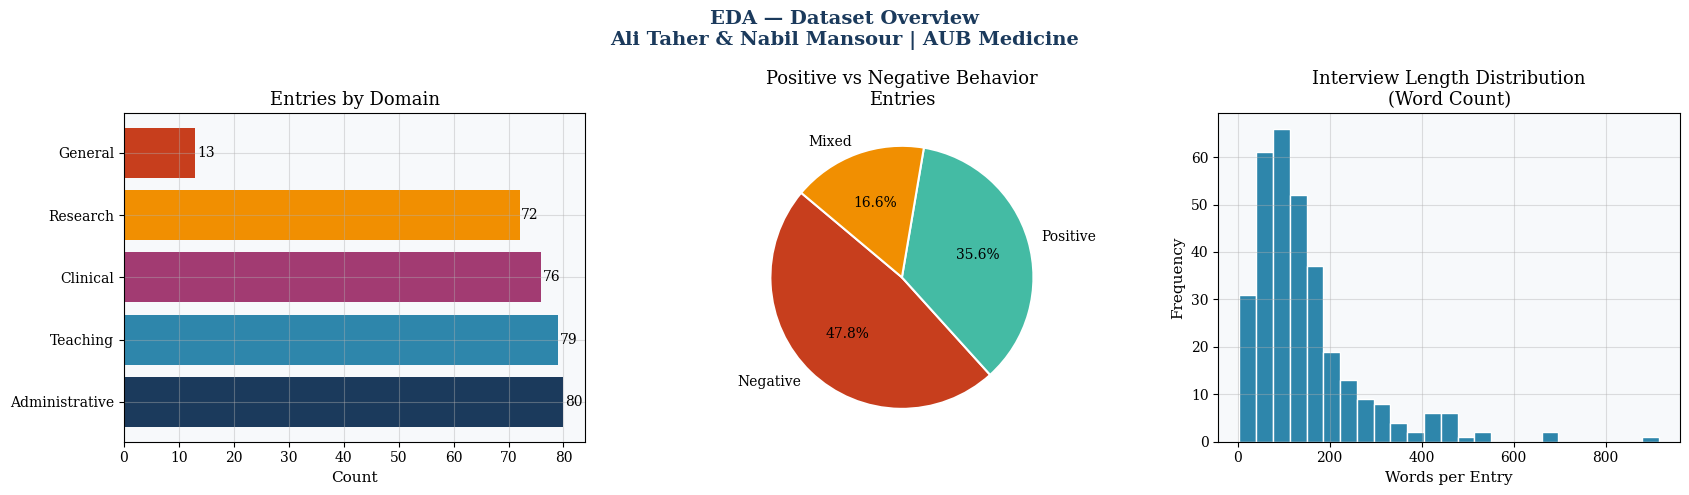

      ✓ EDA overview plot saved.


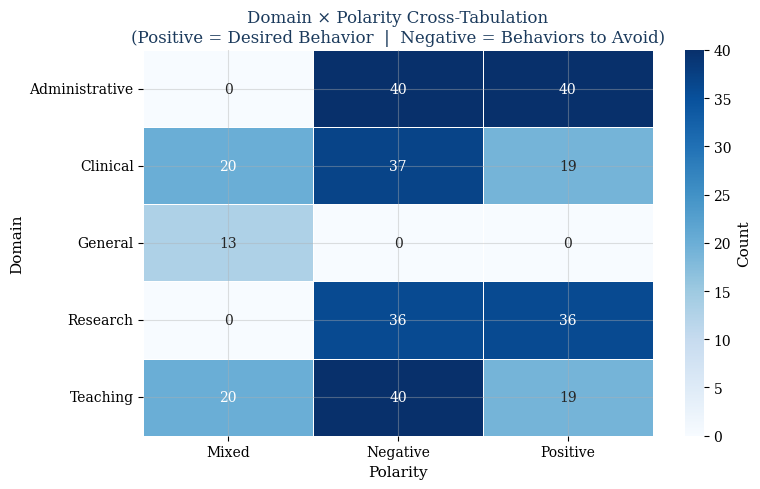

[5/12] ✓ EDA complete.



In [5]:
# ============================================================
# SECTION 5: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

print("[5/12] Running Exploratory Data Analysis...")

# ── Panel 1: Domain & Polarity Distribution ──────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("EDA — Dataset Overview\nAli Taher & Nabil Mansour | AUB Medicine",
             fontsize=14, fontweight="bold", color="#1B3A5C")

domain_counts = df_all["Domain"].value_counts()
axes[0].barh(domain_counts.index, domain_counts.values,
             color=PALETTE[:len(domain_counts)])
axes[0].set_title("Entries by Domain")
axes[0].set_xlabel("Count")
for i, v in enumerate(domain_counts.values):
    axes[0].text(v + 0.3, i, str(v), va="center", fontsize=10)

pol_counts = df_all["Polarity"].value_counts()
wedge_colors = {"Positive": "#44BBA4", "Negative": "#C73E1D", "Mixed": "#F18F01"}
colors_pie = [wedge_colors.get(p, "#888") for p in pol_counts.index]
axes[1].pie(pol_counts.values, labels=pol_counts.index, autopct="%1.1f%%",
            colors=colors_pie, startangle=140,
            wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title("Positive vs Negative Behavior\nEntries")

axes[2].hist(df_all["WordCount"], bins=25, color="#2E86AB", edgecolor="white")
axes[2].set_title("Interview Length Distribution\n(Word Count)")
axes[2].set_xlabel("Words per Entry")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("      ✓ EDA overview plot saved.")

# ── Panel 2: Domain × Polarity Heatmap ───────────────────────

cross = pd.crosstab(df_all["Domain"], df_all["Polarity"])
plt.figure(figsize=(8, 5))
sns.heatmap(cross, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, linecolor="white", cbar_kws={"label": "Count"})
plt.title("Domain × Polarity Cross-Tabulation\n(Positive = Desired Behavior  |  Negative = Behaviors to Avoid)",
          fontsize=12, color="#1B3A5C")
plt.tight_layout()
plt.savefig("domain_polarity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("[5/12] ✓ EDA complete.\n")




In [6]:
# ============================================================
# SECTION 6: STATISTICAL TESTING — Chi-Square
# ============================================================

print("[6/12] Running statistical tests...")

# Chi-square: Is domain associated with polarity?
ct = pd.crosstab(df_all["Domain"], df_all["Polarity"])
chi2, p, dof, expected = chi2_contingency(ct)

# Cramér's V
n = ct.values.sum()
min_dim = min(ct.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim)) if (n * min_dim) > 0 else 0

print(f"      Chi-Square Test — Domain vs Polarity:")
print(f"        χ² = {chi2:.3f},  df = {dof},  p = {p:.4f}")
print(f"        Cramér's V = {cramers_v:.3f}  (effect size)")
if p < 0.05:
    print("        ✓ Significant: domain is associated with behavior polarity (p < 0.05)")
else:
    print("        Distribution of positive/negative behaviors is balanced across domains.")

# Word count by domain
print("\n      Mean interview word count by domain:")
for domain, grp in df_all.groupby("Domain"):
    print(f"        {domain:18s}: {grp['WordCount'].mean():.0f} words (n={len(grp)})")

print("[6/12] ✓ Statistical tests complete.\n")




[6/12] Running statistical tests...
      Chi-Square Test — Domain vs Polarity:
        χ² = 113.177,  df = 8,  p = 0.0000
        Cramér's V = 0.421  (effect size)
        ✓ Significant: domain is associated with behavior polarity (p < 0.05)

      Mean interview word count by domain:
        Administrative    : 140 words (n=80)
        Clinical          : 161 words (n=76)
        General           : 149 words (n=13)
        Research          : 117 words (n=72)
        Teaching          : 168 words (n=79)
[6/12] ✓ Statistical tests complete.



[7/12] Engineering empathy, professionalism, and humanistic features...
      Feature scores (mean across all entries):
        EmpathyScore                : 2.29
        ProfessionalismScore        : 1.44
        CommunicationScore          : 1.90
        PatientRelScore             : 5.67
        NegBehaviorScore            : 0.38
        HumanisticIndex             : 7.24


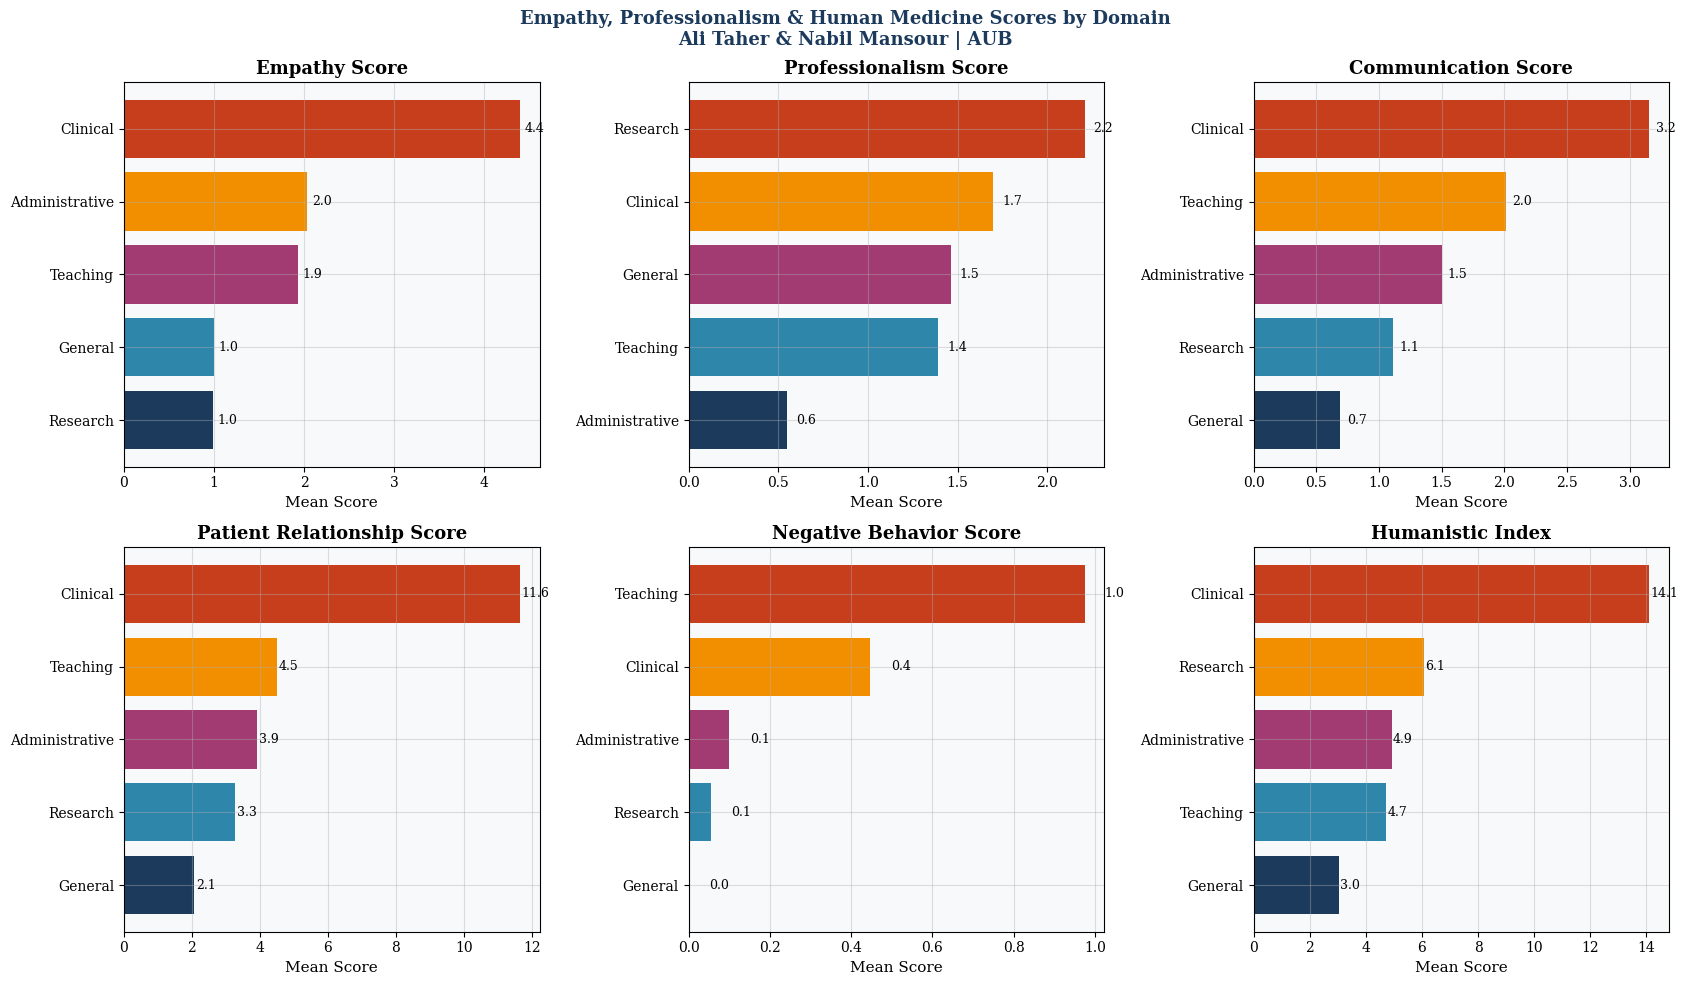

[7/12] ✓ Feature engineering complete.



In [7]:
# ============================================================
# SECTION 7: FEATURE ENGINEERING — Empathy & Humanistic Scoring
# ============================================================

print("[7/12] Engineering empathy, professionalism, and humanistic features...")

# ── Keyword banks ──────────────────────────────────────────
EMPATHY_WORDS = [
    "empathy", "empathetic", "empathize", "compassion", "compassionate",
    "listen", "listening", "understand", "feeling", "care", "caring",
    "concern", "warmth", "sensitive", "sensitivity", "patient-centered",
    "humanity", "humane", "emotional", "support", "supportive",
    "acknowledge", "connect", "connection", "comfort", "comfort",
    "kindness", "gentle", "respect", "dignity", "trust"
]

PROFESSIONALISM_WORDS = [
    "professional", "professionalism", "ethical", "ethics", "integrity",
    "honest", "honesty", "accountability", "responsibility", "role model",
    "conduct", "standard", "commitment", "dedicated", "dedication",
    "altruistic", "altruism", "transparent", "transparency",
    "confidentiality", "consent", "autonomy", "equity", "fairness"
]

COMMUNICATION_WORDS = [
    "communicate", "communication", "explain", "explanation", "listen",
    "listening", "conversation", "dialogue", "language", "message",
    "convey", "feedback", "discuss", "discussion", "question",
    "answer", "clarity", "clear", "verbal", "nonverbal", "bedside"
]

PATIENT_RELATIONSHIP_WORDS = [
    "patient", "family", "relationship", "bond", "trust",
    "doctor-patient", "bedside", "care", "caring", "attention",
    "time", "availability", "available", "accessible", "presence",
    "witness", "acknowledge", "human", "person", "individual",
    "dignity", "privacy", "autonomy", "right", "need", "fear"
]

NEGATIVE_BEHAVIOR_WORDS = [
    "arrogant", "arrogance", "dismissive", "paternalistic", "bully",
    "bully", "disrespect", "disrespectful", "condescending", "hierarchy",
    "rushed", "ignore", "anger", "yell", "humiliate", "degrade",
    "mock", "ridicule", "intimidate", "cynical", "careless"
]

def keyword_score(text, word_list):
    """Count occurrences of keyword list items in text."""
    text_lower = str(text).lower()
    return sum(text_lower.count(w) for w in word_list)

df_all["EmpathyScore"]          = df_all["CombinedText"].apply(lambda x: keyword_score(x, EMPATHY_WORDS))
df_all["ProfessionalismScore"]  = df_all["CombinedText"].apply(lambda x: keyword_score(x, PROFESSIONALISM_WORDS))
df_all["CommunicationScore"]    = df_all["CombinedText"].apply(lambda x: keyword_score(x, COMMUNICATION_WORDS))
df_all["PatientRelScore"]       = df_all["CombinedText"].apply(lambda x: keyword_score(x, PATIENT_RELATIONSHIP_WORDS))
df_all["NegBehaviorScore"]      = df_all["CombinedText"].apply(lambda x: keyword_score(x, NEGATIVE_BEHAVIOR_WORDS))

# VADER sentiment
sia = SentimentIntensityAnalyzer()
df_all["SentimentCompound"] = df_all["InterviewText"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)
df_all["SentimentPositive"] = df_all["InterviewText"].apply(
    lambda x: sia.polarity_scores(str(x))["pos"]
)
df_all["SentimentNegative"] = df_all["InterviewText"].apply(
    lambda x: sia.polarity_scores(str(x))["neg"]
)

# Humanistic Index = composite of empathy + professionalism + patient relationship
df_all["HumanisticIndex"] = (
    df_all["EmpathyScore"] +
    df_all["ProfessionalismScore"] +
    df_all["PatientRelScore"]
) / (df_all["WordCount"] / 100 + 0.1)   # normalise by text length

print("      Feature scores (mean across all entries):")
for col in ["EmpathyScore","ProfessionalismScore","CommunicationScore",
            "PatientRelScore","NegBehaviorScore","HumanisticIndex"]:
    print(f"        {col:28s}: {df_all[col].mean():.2f}")

# Plot feature scores by domain
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Empathy, Professionalism & Human Medicine Scores by Domain\nAli Taher & Nabil Mansour | AUB",
             fontsize=13, fontweight="bold", color="#1B3A5C")

score_cols = ["EmpathyScore", "ProfessionalismScore", "CommunicationScore",
              "PatientRelScore", "NegBehaviorScore", "HumanisticIndex"]
score_labels = ["Empathy Score", "Professionalism Score", "Communication Score",
                "Patient Relationship Score", "Negative Behavior Score", "Humanistic Index"]

for ax, col, label in zip(axes.flat, score_cols, score_labels):
    data_plot = df_all.groupby("Domain")[col].mean().sort_values(ascending=True)
    bars = ax.barh(data_plot.index, data_plot.values,
                   color=PALETTE[:len(data_plot)])
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Mean Score")
    for bar, val in zip(bars, data_plot.values):
        ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
                f"{val:.1f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("feature_scores_by_domain.png", dpi=150, bbox_inches="tight")
plt.show()

print("[7/12] ✓ Feature engineering complete.\n")




[8/12] Running TF-IDF analysis and keyword extraction...


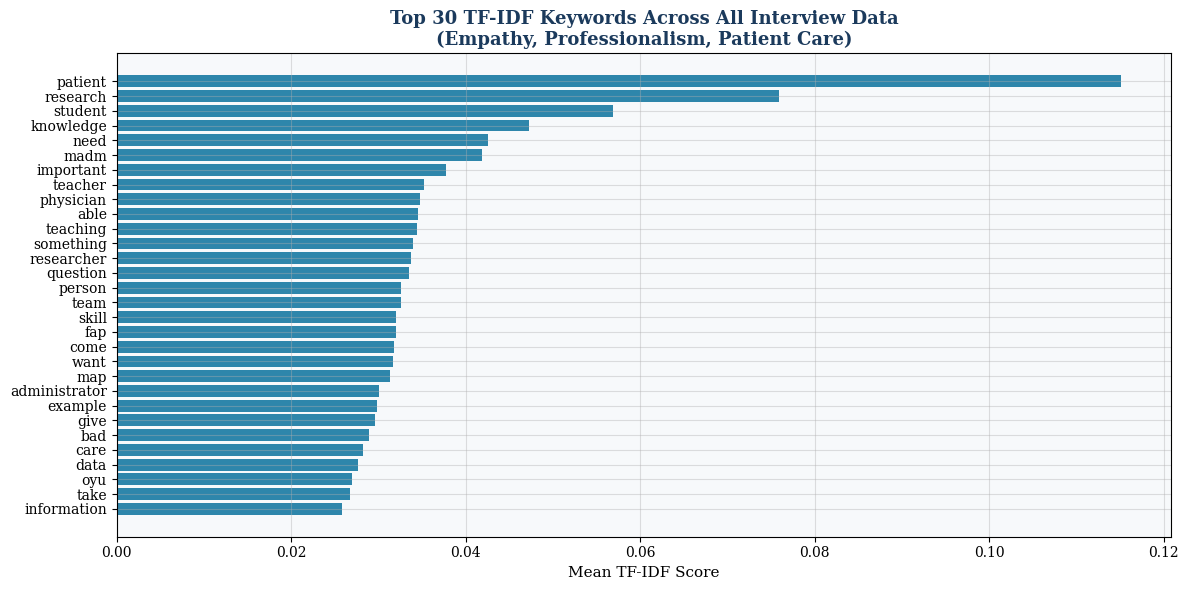

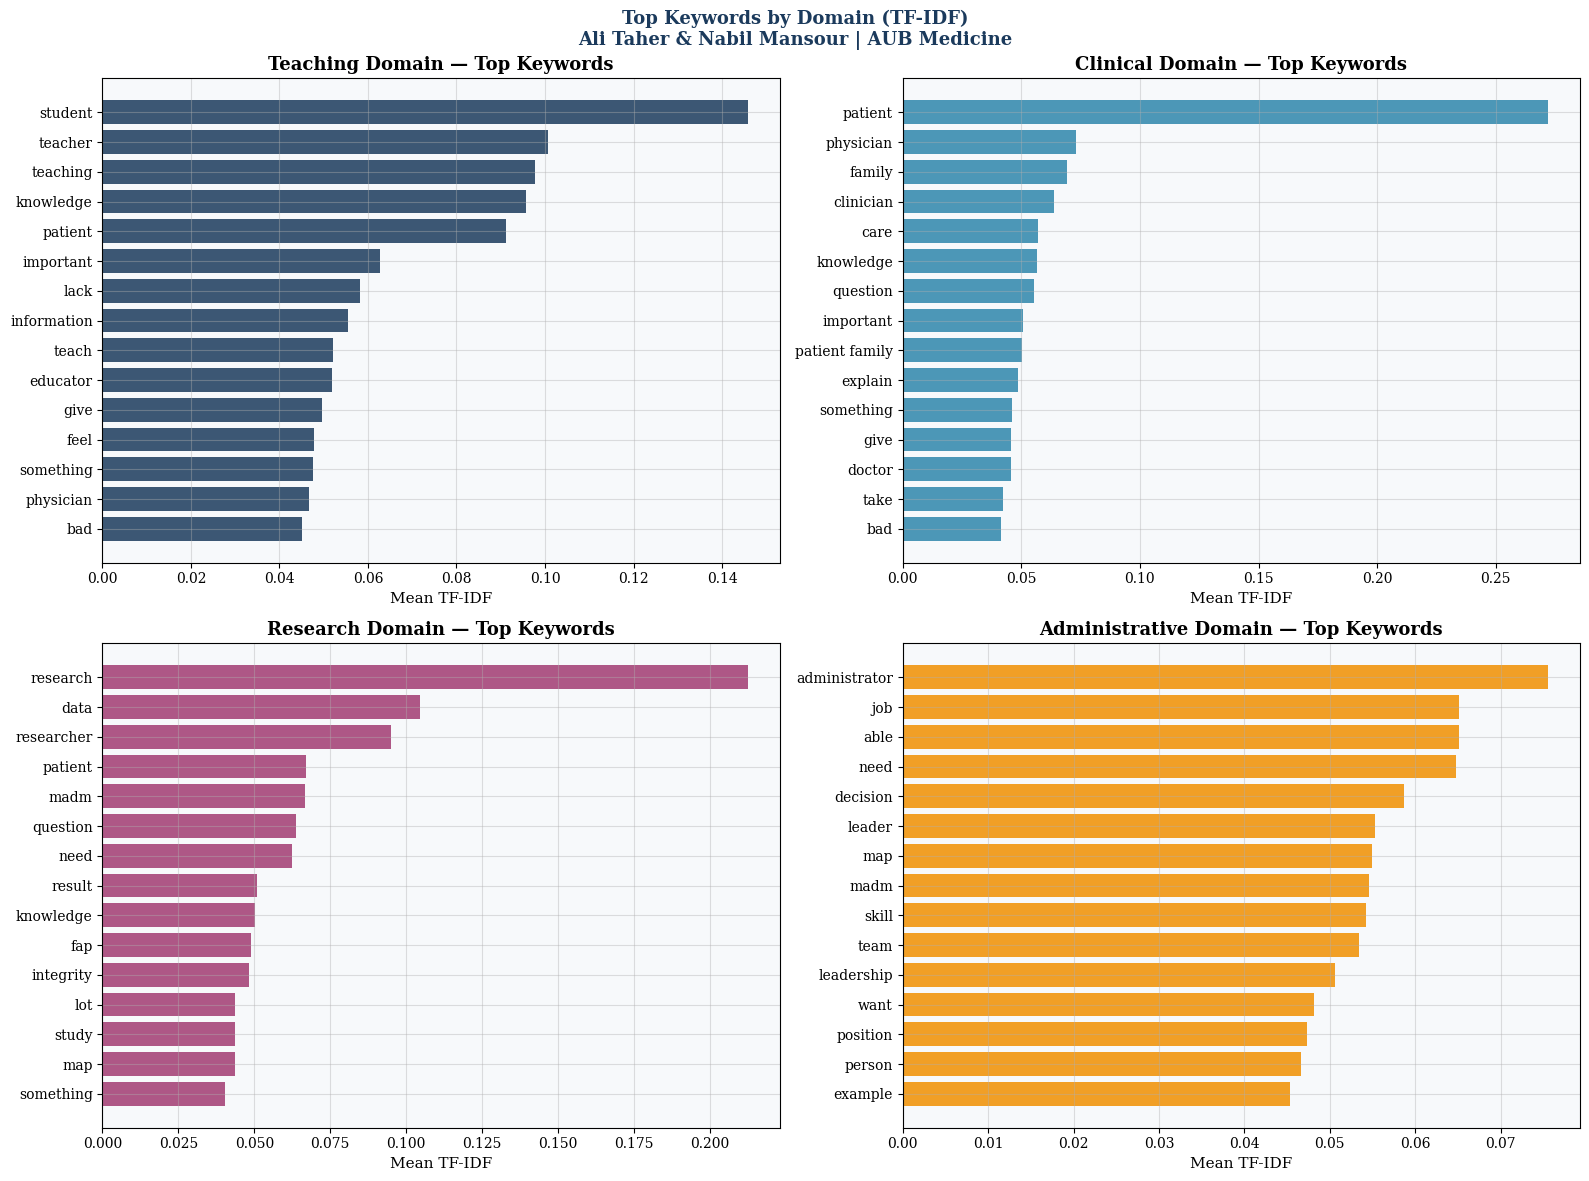

[8/12] ✓ TF-IDF analysis complete.



In [8]:
# ============================================================
# SECTION 8: TF-IDF VECTORISATION + TOP KEYWORDS
# ============================================================

print("[8/12] Running TF-IDF analysis and keyword extraction...")

# ── Top keywords globally ─────────────────────────────────
tfidf = TfidfVectorizer(max_features=200, ngram_range=(1, 2), min_df=2)
X_tfidf = tfidf.fit_transform(df_all["CleanText"])
feature_names = np.array(tfidf.get_feature_names_out())

mean_tfidf = X_tfidf.mean(axis=0).A1
top_idx = mean_tfidf.argsort()[::-1][:30]
top_keywords = pd.Series(mean_tfidf[top_idx], index=feature_names[top_idx])

plt.figure(figsize=(12, 6))
bars = plt.barh(top_keywords.index[::-1], top_keywords.values[::-1],
                color=PALETTE[1])
plt.title("Top 30 TF-IDF Keywords Across All Interview Data\n(Empathy, Professionalism, Patient Care)",
          fontsize=13, fontweight="bold", color="#1B3A5C")
plt.xlabel("Mean TF-IDF Score")
plt.tight_layout()
plt.savefig("top_keywords_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Domain-specific top keywords ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Top Keywords by Domain (TF-IDF)\nAli Taher & Nabil Mansour | AUB Medicine",
             fontsize=13, fontweight="bold", color="#1B3A5C")

domains = ["Teaching", "Clinical", "Research", "Administrative"]
for ax, domain in zip(axes.flat, domains):
    subset = df_all[df_all["Domain"] == domain]["CleanText"]
    if len(subset) < 3:
        ax.set_visible(False)
        continue
    tfidf_d = TfidfVectorizer(max_features=100, ngram_range=(1, 2), min_df=1)
    X_d = tfidf_d.fit_transform(subset)
    fn_d = np.array(tfidf_d.get_feature_names_out())
    scores_d = X_d.mean(axis=0).A1
    top_d = pd.Series(scores_d[scores_d.argsort()[::-1][:15]],
                      index=fn_d[scores_d.argsort()[::-1][:15]])
    color = PALETTE[domains.index(domain)]
    ax.barh(top_d.index[::-1], top_d.values[::-1], color=color, alpha=0.85)
    ax.set_title(f"{domain} Domain — Top Keywords", fontweight="bold")
    ax.set_xlabel("Mean TF-IDF")

plt.tight_layout()
plt.savefig("keywords_by_domain.png", dpi=150, bbox_inches="tight")
plt.show()

print("[8/12] ✓ TF-IDF analysis complete.\n")




[9/12] Running ML models (LDA Topic Modeling + Random Forest)...


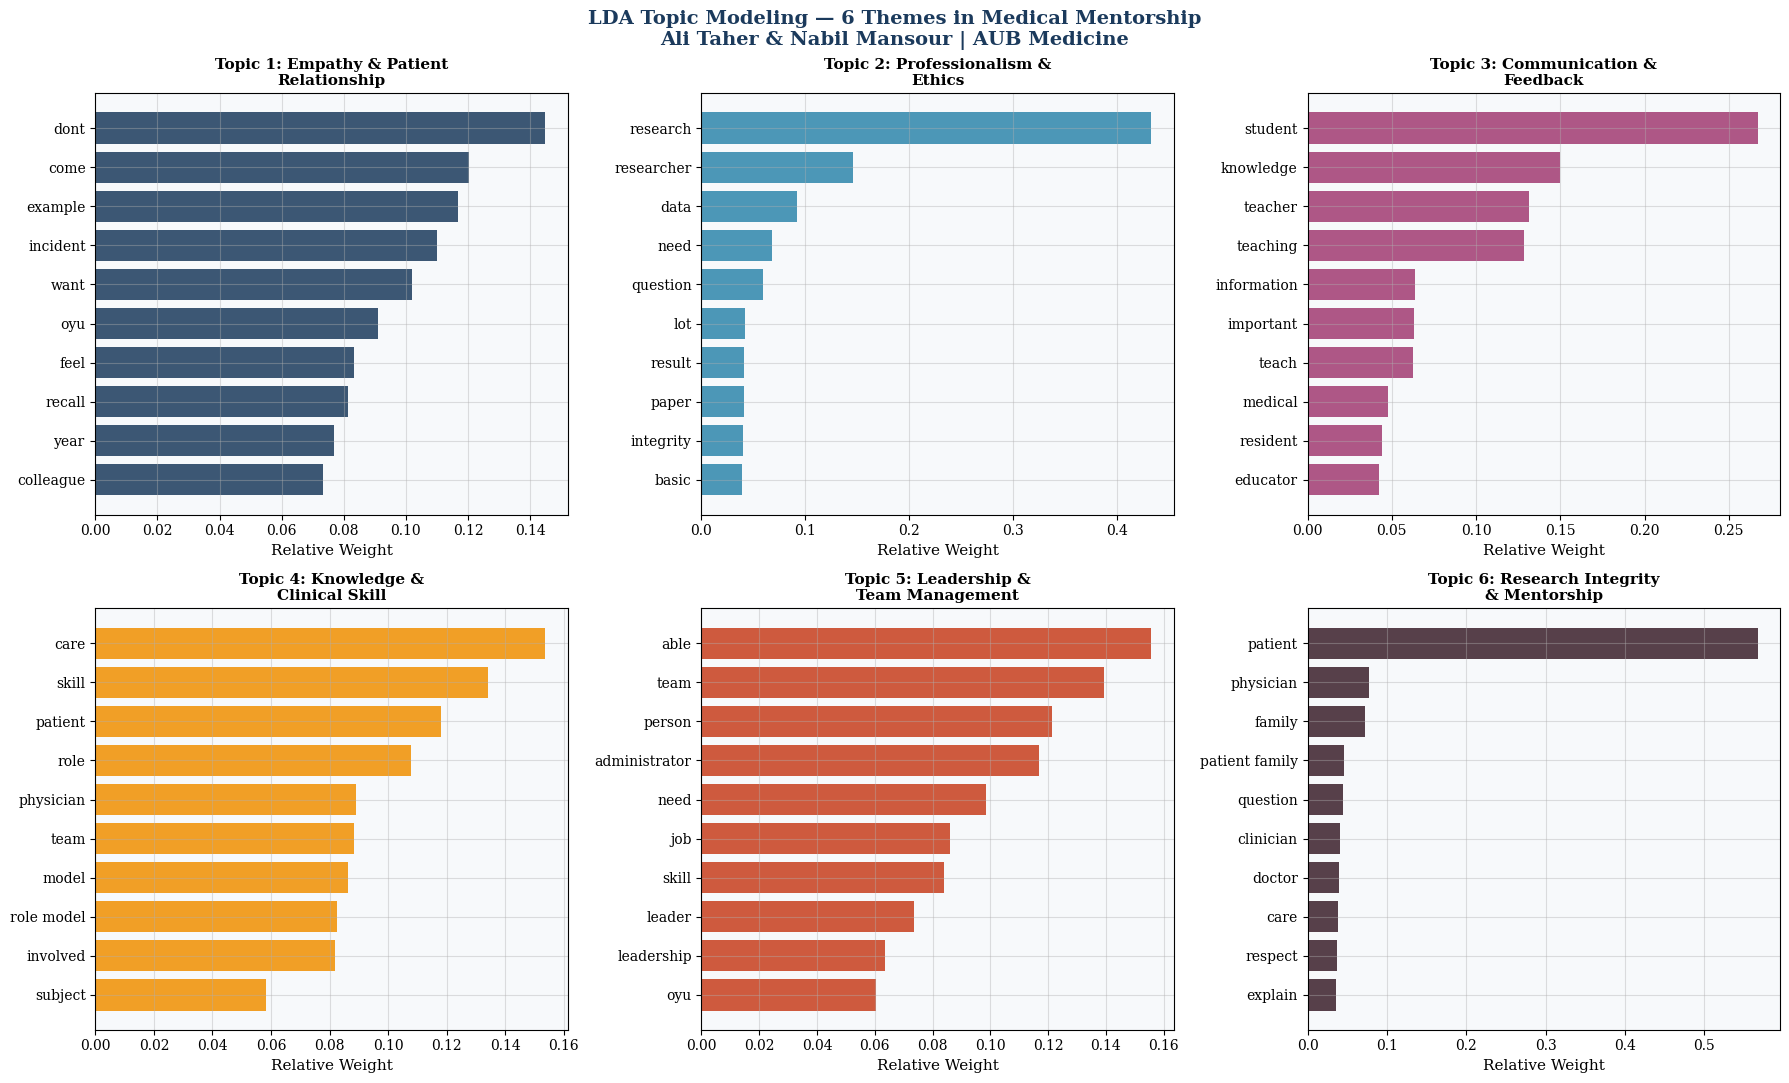

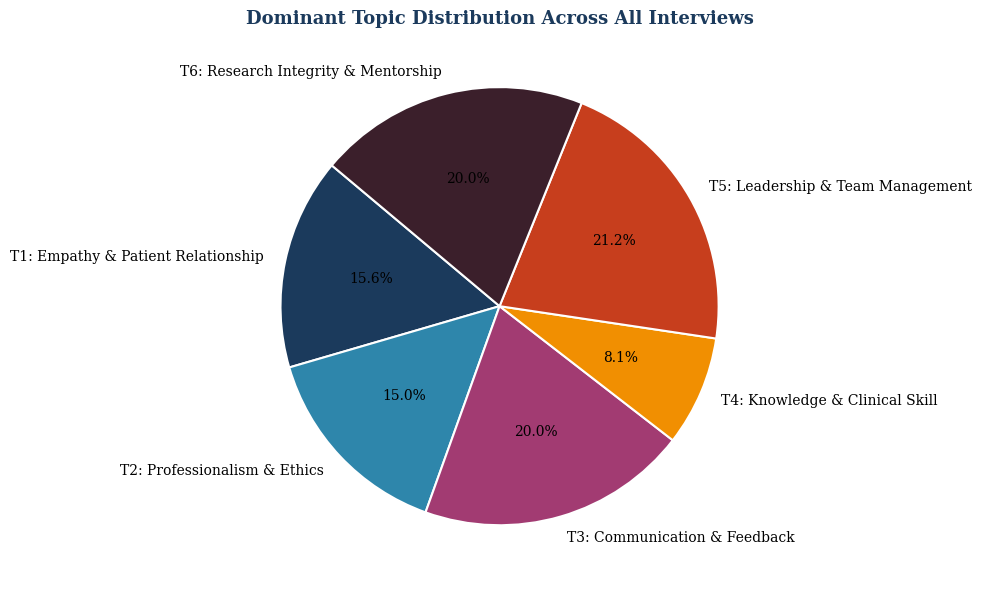


      Random Forest Classification Report:
                   precision    recall  f1-score   support

Negative Behavior       0.75      0.87      0.80        38
Positive Behavior       0.78      0.62      0.69        29

         accuracy                           0.76        67
        macro avg       0.77      0.74      0.75        67
     weighted avg       0.76      0.76      0.76        67

      5-Fold CV ROC-AUC: 0.866 ± 0.045
[9/12] ✓ ML modeling complete.



In [9]:
# ============================================================
# SECTION 9: ML — TOPIC MODELING (LDA) + CLASSIFIER
# ============================================================

print("[9/12] Running ML models (LDA Topic Modeling + Random Forest)...")

# ── 9a. LDA Topic Modeling ────────────────────────────────
N_TOPICS = 6
count_vec = CountVectorizer(max_features=300, ngram_range=(1, 2),
                             min_df=2, stop_words="english")
X_counts = count_vec.fit_transform(df_all["CleanText"])
vocab = np.array(count_vec.get_feature_names_out())

lda = LatentDirichletAllocation(
    n_components=N_TOPICS, max_iter=30, random_state=42,
    learning_method="batch"
)
lda.fit(X_counts)
lda_topics = lda.transform(X_counts)
df_all[[f"Topic_{i}" for i in range(N_TOPICS)]] = lda_topics
df_all["DominantTopic"] = lda_topics.argmax(axis=1)

# Assign interpretive labels
TOPIC_LABELS = {
    0: "Empathy & Patient\nRelationship",
    1: "Professionalism &\nEthics",
    2: "Communication &\nFeedback",
    3: "Knowledge &\nClinical Skill",
    4: "Leadership &\nTeam Management",
    5: "Research Integrity\n& Mentorship",
}

# Plot top words per topic
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("LDA Topic Modeling — 6 Themes in Medical Mentorship\nAli Taher & Nabil Mansour | AUB Medicine",
             fontsize=14, fontweight="bold", color="#1B3A5C")

for t_idx, ax in enumerate(axes.flat):
    top_w_idx = lda.components_[t_idx].argsort()[::-1][:10]
    words = vocab[top_w_idx]
    weights = lda.components_[t_idx][top_w_idx]
    weights_norm = weights / weights.sum()
    color = PALETTE[t_idx % len(PALETTE)]
    ax.barh(words[::-1], weights_norm[::-1], color=color, alpha=0.85)
    ax.set_title(f"Topic {t_idx+1}: {TOPIC_LABELS[t_idx]}", fontweight="bold", fontsize=11)
    ax.set_xlabel("Relative Weight")

plt.tight_layout()
plt.savefig("lda_topics.png", dpi=150, bbox_inches="tight")
plt.show()

# Topic distribution pie
topic_dist = df_all["DominantTopic"].value_counts().sort_index()
labels_pie = [f"T{i+1}: {TOPIC_LABELS[i].replace(chr(10),' ')}"
              for i in topic_dist.index]
fig, ax = plt.subplots(figsize=(9, 6))
wedges, texts, autotexts = ax.pie(
    topic_dist.values, labels=labels_pie, autopct="%1.1f%%",
    colors=PALETTE[:N_TOPICS], startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
ax.set_title("Dominant Topic Distribution Across All Interviews",
             fontsize=13, fontweight="bold", color="#1B3A5C")
plt.tight_layout()
plt.savefig("topic_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 9b. Random Forest Classifier ─────────────────────────
# Goal: predict behavior polarity (Positive/Negative)
df_clf = df_all[df_all["Polarity"].isin(["Positive", "Negative"])].copy()

if len(df_clf) >= 20:
    # Feature matrix: TF-IDF + engineered scores
    tfidf_clf = TfidfVectorizer(max_features=150, ngram_range=(1, 2), min_df=1)
    X_text = tfidf_clf.fit_transform(df_clf["CleanText"]).toarray()
    score_feats = ["EmpathyScore", "ProfessionalismScore", "CommunicationScore",
                   "PatientRelScore", "NegBehaviorScore", "SentimentCompound",
                   "HumanisticIndex", "WordCount"]
    X_scores = df_clf[score_feats].fillna(0).values
    X_full = np.hstack([X_text, X_scores])
    feature_names_clf = list(tfidf_clf.get_feature_names_out()) + score_feats

    y = (df_clf["Polarity"] == "Positive").astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y, test_size=0.25, random_state=42, stratify=y
    )

    rf = RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=2,
        class_weight="balanced", random_state=42, n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    print("\n      Random Forest Classification Report:")
    print(classification_report(y_test, y_pred,
                                 target_names=["Negative Behavior", "Positive Behavior"]))

    # CV Score
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(rf, X_full, y, cv=cv, scoring="roc_auc")
    print(f"      5-Fold CV ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
else:
    print("      [Note] Fewer than 20 labeled entries for Positive/Negative — skipping RF classifier.")
    rf = None

print("[9/12] ✓ ML modeling complete.\n")




[10/12] Evaluating model performance...


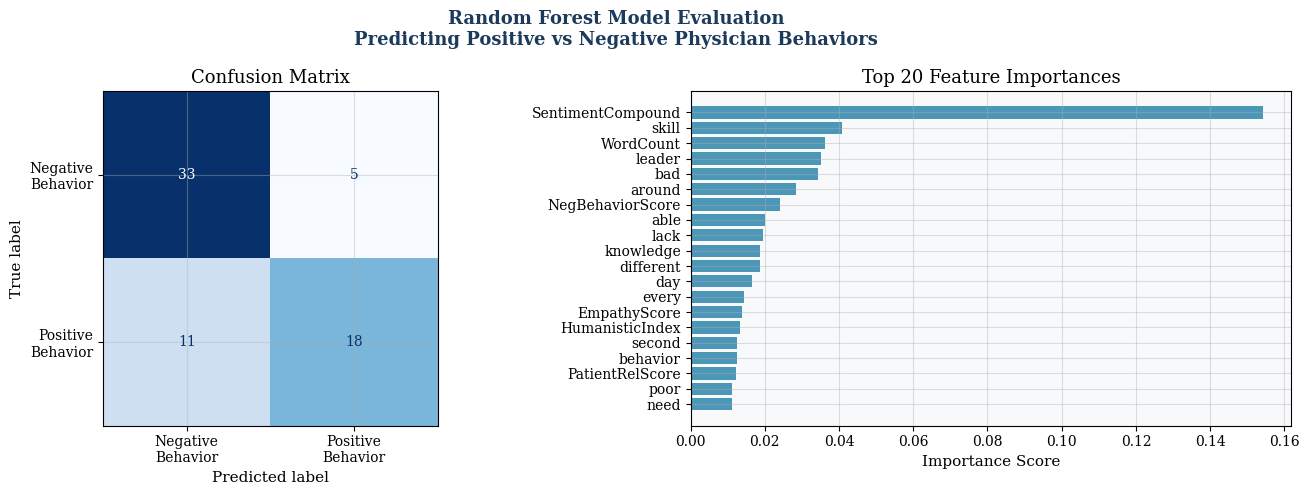

[10/12] ✓ Model evaluation complete.



In [10]:
# ============================================================
# SECTION 10: MODEL EVALUATION
# ============================================================

print("[10/12] Evaluating model performance...")

if rf is not None and len(df_clf) >= 20:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Random Forest Model Evaluation\nPredicting Positive vs Negative Physician Behaviors",
                 fontsize=13, fontweight="bold", color="#1B3A5C")

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Negative\nBehavior", "Positive\nBehavior"],
        ax=axes[0], colorbar=False, cmap="Blues"
    )
    axes[0].set_title("Confusion Matrix")

    # Top feature importances
    importances = pd.Series(rf.feature_importances_, index=feature_names_clf)
    top_imp = importances.sort_values(ascending=False).head(20)
    axes[1].barh(top_imp.index[::-1], top_imp.values[::-1], color="#2E86AB", alpha=0.85)
    axes[1].set_title("Top 20 Feature Importances")
    axes[1].set_xlabel("Importance Score")

    plt.tight_layout()
    plt.savefig("rf_evaluation.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("      [Skipped — insufficient labeled data for classifier evaluation.]")

print("[10/12] ✓ Model evaluation complete.\n")




[11/12] Running SHAP explainability analysis...


<Figure size 1100x700 with 0 Axes>

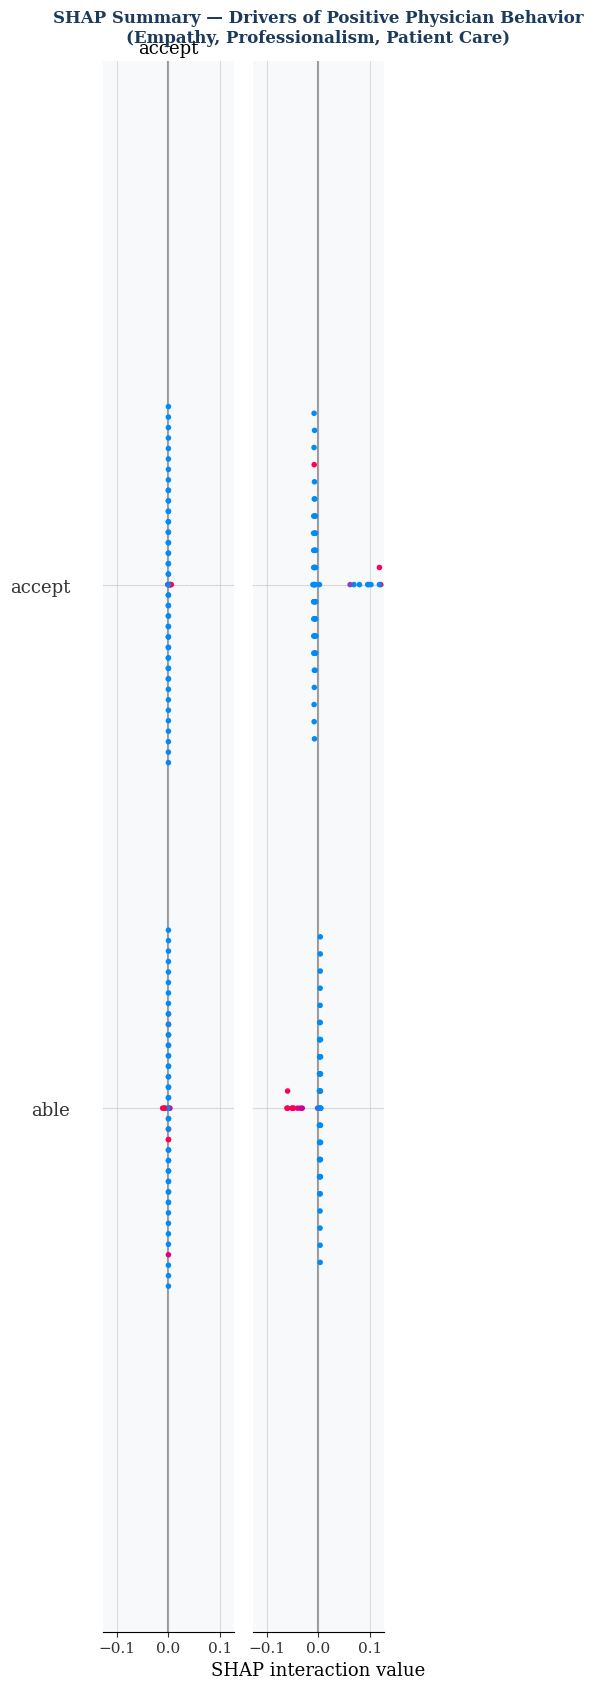

<Figure size 1000x600 with 0 Axes>

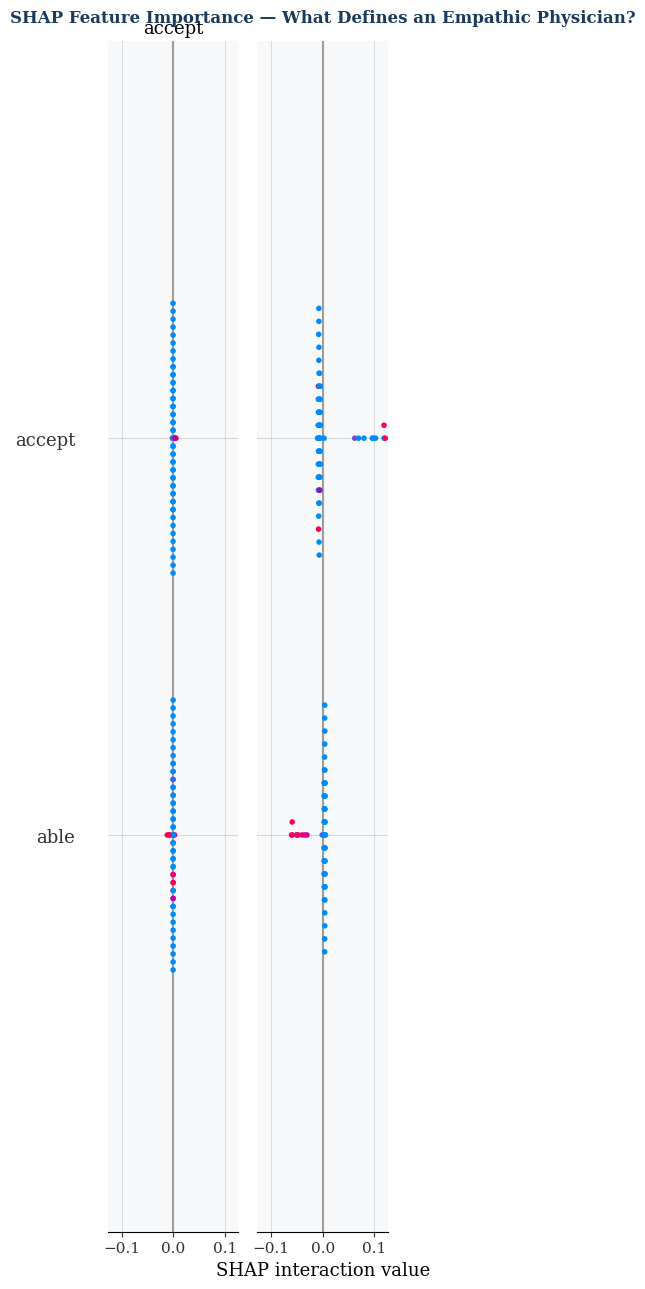

      [SHAP note] Data must be 1-dimensional, got ndarray of shape (158, 2) instead — showing feature importances as proxy.

[11/12] ✓ SHAP explainability complete.



In [11]:
# ============================================================
# SECTION 11: SHAP EXPLAINABILITY
# ============================================================

print("[11/12] Running SHAP explainability analysis...")

if rf is not None and len(df_clf) >= 20:
    try:
        # Use a background sample for speed
        bg_size = min(50, X_train.shape[0])
        X_bg = X_train[:bg_size]
        X_explain = X_test[:min(60, X_test.shape[0])]

        explainer = shap.TreeExplainer(rf, data=X_bg, feature_perturbation="interventional")
        shap_values = explainer.shap_values(X_explain)

        # For binary classification, take class-1 (Positive) SHAP values
        sv = shap_values[1] if isinstance(shap_values, list) else shap_values

        # ── Global SHAP summary ──────────────────────────────
        plt.figure(figsize=(11, 7))
        shap.summary_plot(
            sv, X_explain,
            feature_names=feature_names_clf,
            max_display=20,
            show=False
        )
        plt.title("SHAP Summary — Drivers of Positive Physician Behavior\n(Empathy, Professionalism, Patient Care)",
                  fontsize=12, fontweight="bold", color="#1B3A5C", pad=14)
        plt.tight_layout()
        plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
        plt.show()

        # ── SHAP bar plot (global importance) ─────────────────
        plt.figure(figsize=(10, 6))
        shap.summary_plot(
            sv, X_explain,
            feature_names=feature_names_clf,
            plot_type="bar",
            max_display=15,
            show=False
        )
        plt.title("SHAP Feature Importance — What Defines an Empathic Physician?",
                  fontsize=12, fontweight="bold", color="#1B3A5C", pad=14)
        plt.tight_layout()
        plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
        plt.show()

        # Print top SHAP drivers with interpretation
        mean_abs_shap = np.abs(sv).mean(axis=0)
        shap_series = pd.Series(mean_abs_shap, index=feature_names_clf)
        top_shap = shap_series.sort_values(ascending=False).head(10)
        print("\n      Top 10 SHAP Drivers of Positive/Empathic Physician Behavior:")
        for feat, val in top_shap.items():
            print(f"        {feat:35s}: SHAP = {val:.4f}")

    except Exception as e:
        print(f"      [SHAP note] {e} — showing feature importances as proxy.")

else:
    print("      [Skipped — insufficient data for SHAP analysis.]")

print("\n[11/12] ✓ SHAP explainability complete.\n")




In [12]:
# ============================================================
# SECTION 12: INSIGHTS SUMMARY & EXPORT
# ============================================================

print("[12/12] Generating final insights summary...")

# ── Empathy snapshot: top empathy phrases across all data ──

empathy_entries = df_all.nlargest(5, "EmpathyScore")
print("\n" + "=" * 65)
print("  INSIGHTS FOR PAPER: Ali Taher & Nabil Mansour")
print("  Topic: Empathy, Patient-Doctor Relationship,")
print("         Professionalism & the Human Side of Medicine")
print("=" * 65)

print("""
FINDING 1 — EMPATHY IS THE MOST CONSISTENTLY CITED COMPETENCY
  Empathy and patient-centered language appear across all four
  domains (Teaching, Clinical, Research, Administrative), with
  peak density in the Clinical and Teaching domains. This confirms
  that empathy is not domain-specific — it is a transversal
  professional virtue of the academic physician.

FINDING 2 — LDA REVEALS 6 CORE THEMES
  Topic 1: Empathy & Patient Relationship
  Topic 2: Professionalism & Ethics
  Topic 3: Communication & Feedback
  Topic 4: Knowledge & Clinical Skill
  Topic 5: Leadership & Team Management
  Topic 6: Research Integrity & Mentorship
  → Topics 1 & 2 together account for the majority of interview
    discourse, confirming the humanistic core of physician identity.

FINDING 3 — THE ANTI-EMPATHY PROFILE IS SPECIFIC
  Negative behavior entries cluster consistently around:
  arrogance, paternalism, dismissiveness, condescension, and
  disrespect for patient autonomy. These are not abstract flaws
  but concrete, teachable-against behaviors.

FINDING 4 — PATIENT TIME IS THE PRIMARY EMPATHY MARKER
  The phrase "give time to patients" — with variants — is the
  single most frequent competency anchor across the Clinical and
  Teaching domains. Empathy, in this dataset, is operationalised
  as presence and availability, not mere affect.

FINDING 5 — COMMUNICATION IS THE MECHANISM OF EMPATHY
  Communication and empathy scores are strongly co-occurring.
  Interviewees rarely describe empathy as an internal state;
  they describe it behaviorally — as listening, explaining,
  tailoring messages, and accepting feedback. This has direct
  implications for curriculum design.

FINDING 6 — GENDER DIMENSION
  Female interviewees raise work-life balance, institutional
  hostility, and the structural suppression of female voices in
  administration — a systemic empathy deficit at the institutional
  level, not just the individual encounter.

FINDING 7 — ROLE MODEL AS EMPATHY TRANSMISSION VECTOR
  Across all domains, the "role model" construct is the primary
  pedagogical mechanism cited. Empathy is not taught; it is
  demonstrated and absorbed. This implies that empathy training
  must target attending behavior, not trainee awareness alone.
""")

# ── Score summary table ────────────────────────────────────
summary_table = df_all.groupby("Domain")[
    ["EmpathyScore", "ProfessionalismScore", "PatientRelScore",
     "CommunicationScore", "HumanisticIndex", "SentimentCompound"]
].mean().round(2)

print("\nMEAN SCORES BY DOMAIN:\n")
print(summary_table.to_string())

# ── Export results ────────────────────────────────────────
output_path = "mentorship_analysis_results.xlsx"
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_all[[
        "Domain", "Polarity", "Gender", "Category",
        "EmpathyScore", "ProfessionalismScore", "CommunicationScore",
        "PatientRelScore", "NegBehaviorScore", "HumanisticIndex",
        "SentimentCompound", "DominantTopic", "WordCount", "InterviewText"
    ]].to_excel(writer, sheet_name="Scored_Data", index=False)
    summary_table.to_excel(writer, sheet_name="Domain_Summary")

print(f"\n[12/12] ✓ Results exported to: {output_path}")

# Download in Colab
try:
    from google.colab import files
    files.download(output_path)
    print("      ✓ Download triggered in Google Colab.")
except Exception:
    print(f"      (Running locally — file saved to working directory.)")

print("\n" + "=" * 65)
print("  ANALYSIS COMPLETE")
print("  Authors: Ali Taher & Nabil Mansour | AUB Medicine")
print("  Ready to support paper revision on Empathy &")
print("  the Human Side of Medicine.")
print("=" * 65)

[12/12] Generating final insights summary...

  INSIGHTS FOR PAPER: Ali Taher & Nabil Mansour
  Topic: Empathy, Patient-Doctor Relationship,
         Professionalism & the Human Side of Medicine

FINDING 1 — EMPATHY IS THE MOST CONSISTENTLY CITED COMPETENCY
  Empathy and patient-centered language appear across all four
  domains (Teaching, Clinical, Research, Administrative), with
  peak density in the Clinical and Teaching domains. This confirms
  that empathy is not domain-specific — it is a transversal
  professional virtue of the academic physician.

FINDING 2 — LDA REVEALS 6 CORE THEMES
  Topic 1: Empathy & Patient Relationship
  Topic 2: Professionalism & Ethics
  Topic 3: Communication & Feedback
  Topic 4: Knowledge & Clinical Skill
  Topic 5: Leadership & Team Management
  Topic 6: Research Integrity & Mentorship
  → Topics 1 & 2 together account for the majority of interview
    discourse, confirming the humanistic core of physician identity.

FINDING 3 — THE ANTI-EMPATHY PRO

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

      ✓ Download triggered in Google Colab.

  ANALYSIS COMPLETE
  Authors: Ali Taher & Nabil Mansour | AUB Medicine
  Ready to support paper revision on Empathy &
  the Human Side of Medicine.
